模型维度:
nlon = 65 nlat = 55 ndep = 14
lon range = 96.0 108.8
lat range = 20.0 30.8
dep range = 0.0 70.0
depths = [ 0.   2.5  5.   7.5 10.  15.  20.  25.  30.  35.  40.  50.  60.  70. ]
depth-layer signs = [ 1. -1.  1. -1.  1. -1.  1. -1.  1. -1.  1. -1.  1. -1.]
MOD 文件已生成: MOD.true


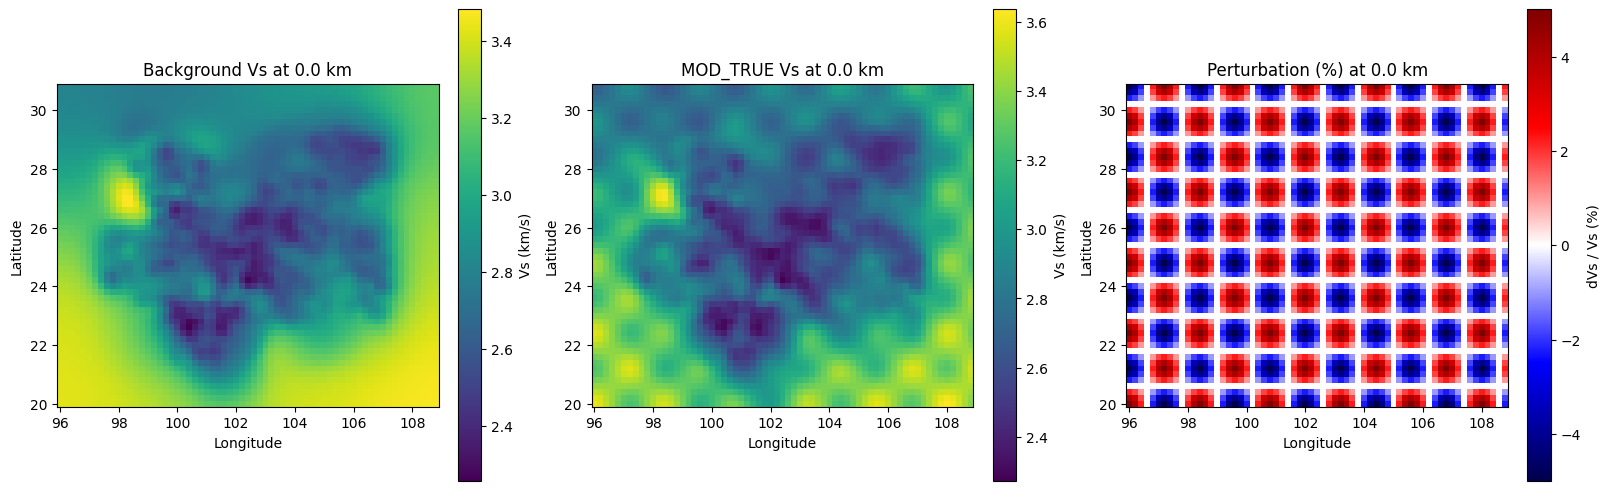

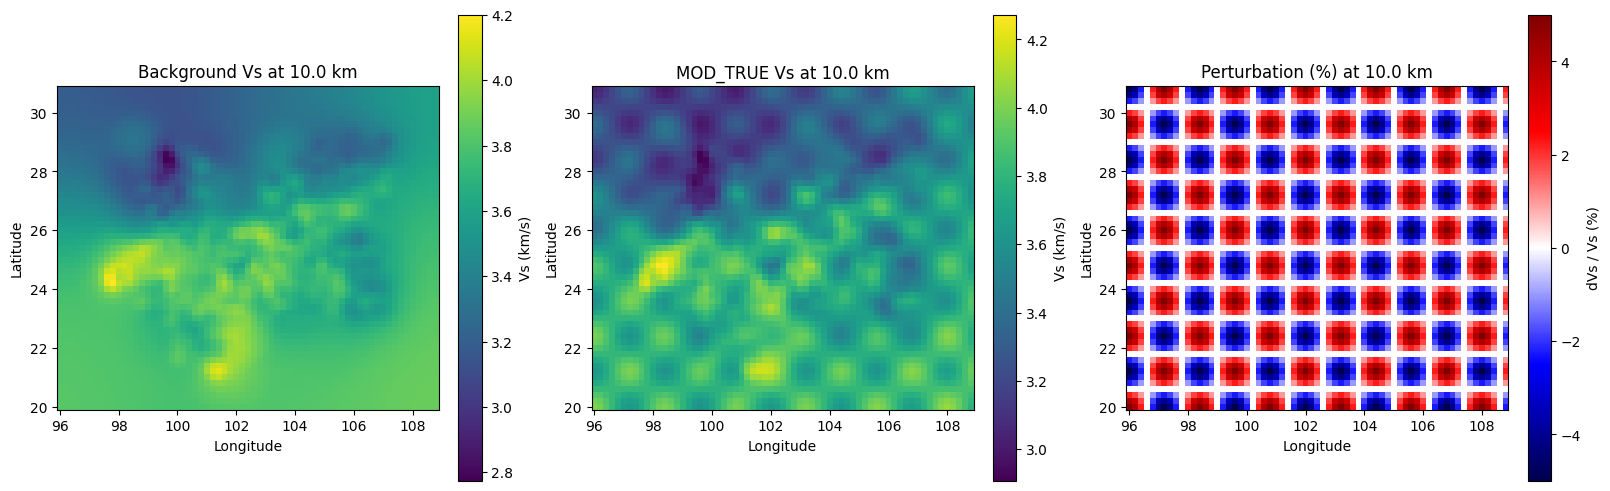

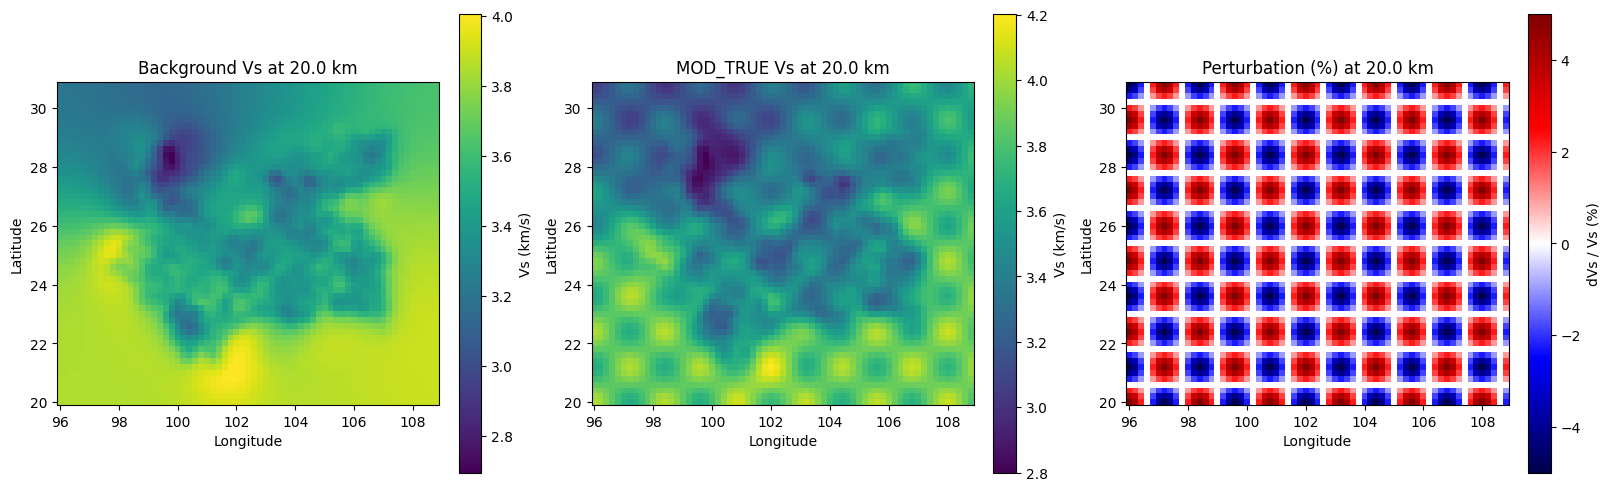

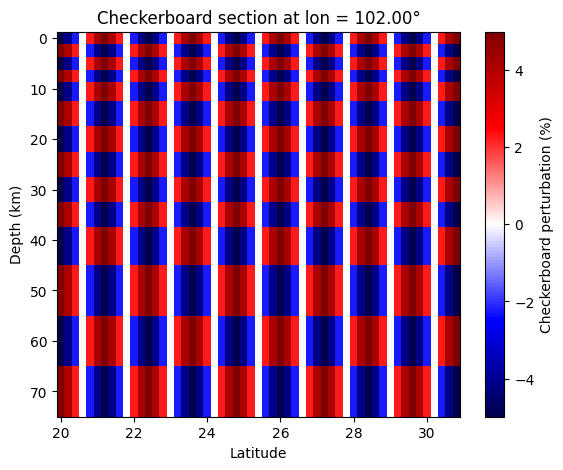

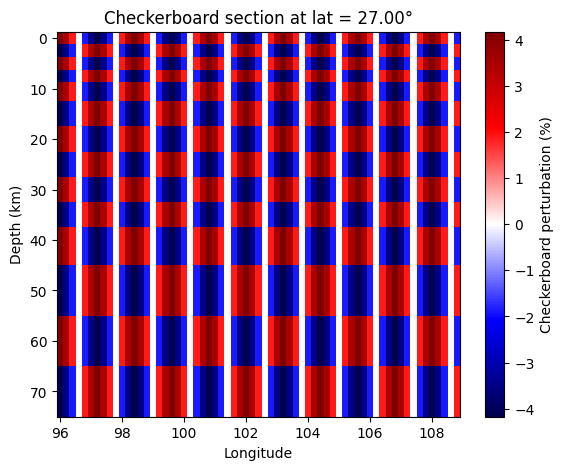

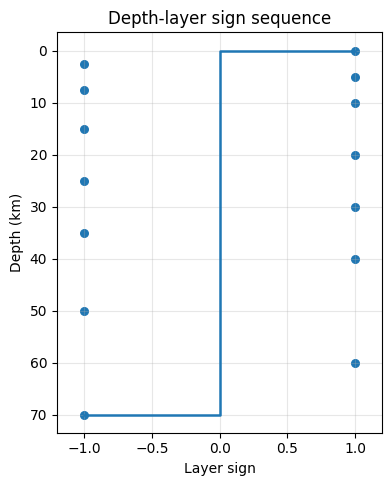

完成：已生成 MOD_TRUE 和 MOD_TRUE.dat


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# 1. 读取四列背景模型
# =========================================================
def read_dat_model(dat_file):
    """
    读取四列格式速度模型:
        lon lat dep vs

    返回:
        lons_sorted : 经度，升序
        lats_sorted : 纬度，降序（北->南）
        deps_sorted : 深度，升序
        vs_3d       : shape = (ndep, nlon, nlat)
                      下标顺序为 [depth, lon, lat]
    """
    data = np.loadtxt(dat_file)

    lon = data[:, 0]
    lat = data[:, 1]
    dep = data[:, 2]
    vs = data[:, 3]

    lons = np.unique(np.round(lon, 6))
    lats = np.unique(np.round(lat, 6))
    deps = np.unique(np.round(dep, 6))

    lons_sorted = np.sort(lons)         # 西 -> 东
    lats_sorted = np.sort(lats)[::-1]   # 北 -> 南
    deps_sorted = np.sort(deps)         # 浅 -> 深

    nlon = len(lons_sorted)
    nlat = len(lats_sorted)
    ndep = len(deps_sorted)

    lon_to_i = {v: i for i, v in enumerate(lons_sorted)}
    lat_to_i = {v: i for i, v in enumerate(lats_sorted)}
    dep_to_i = {v: i for i, v in enumerate(deps_sorted)}

    vs_3d = np.full((ndep, nlon, nlat), np.nan, dtype=float)

    for lo, la, de, vv in data:
        i_lon = lon_to_i[round(lo, 6)]
        i_lat = lat_to_i[round(la, 6)]
        i_dep = dep_to_i[round(de, 6)]
        vs_3d[i_dep, i_lon, i_lat] = vv

    if np.any(np.isnan(vs_3d)):
        raise ValueError("重建三维模型后存在 NaN，说明输入 dat 文件可能不是完整规则网格。")

    return lons_sorted, lats_sorted, deps_sorted, vs_3d


# =========================================================
# 2. 水平方向二维高斯棋盘格
# =========================================================
def gaussian_checkerboard_2d(lons, lats, spacing_lon, spacing_lat,
                             sigma_lon=None, sigma_lat=None):
    """
    构造二维高斯棋盘格场，范围大致在 [-1, 1]
    返回 shape = (nlon, nlat)
    """
    if sigma_lon is None:
        sigma_lon = spacing_lon * 0.35
    if sigma_lat is None:
        sigma_lat = spacing_lat * 0.35

    lon_min, lon_max = lons.min(), lons.max()
    lat_min, lat_max = lats.min(), lats.max()

    centers_lon = np.arange(lon_min, lon_max + 0.5 * spacing_lon, spacing_lon)
    centers_lat = np.arange(lat_min, lat_max + 0.5 * spacing_lat, spacing_lat)

    field = np.zeros((len(lons), len(lats)), dtype=float)

    for i, cx in enumerate(centers_lon):
        for j, cy in enumerate(centers_lat):
            sign = 1.0 if (i + j) % 2 == 0 else -1.0

            dx2 = ((lons[:, None] - cx) ** 2) / (2.0 * sigma_lon ** 2)
            dy2 = ((lats[None, :] - cy) ** 2) / (2.0 * sigma_lat ** 2)
            blob = np.exp(-(dx2 + dy2))

            field += sign * blob

    maxabs = np.max(np.abs(field))
    if maxabs > 0:
        field /= maxabs

    return field


# =========================================================
# 3. 深度方向按离散层号翻号
# =========================================================
def build_vertical_signs(deps, layer_flip_step=1, start_positive=True):
    """
    按真实离散深度层构造正负交替符号

    参数
    ----
    deps : 深度数组（只用于知道有多少层）
    layer_flip_step : 每多少层翻转一次
        =1 表示每层翻一次: 0正 2.5负 5正 ...
        =2 表示每两层翻一次
    start_positive : 第一层是否为正

    返回
    ----
    signs : shape = (ndep,)
    """
    ndep = len(deps)
    signs = np.ones(ndep, dtype=float)

    for idep in range(ndep):
        block_id = idep // layer_flip_step
        sign = 1.0 if (block_id % 2 == 0) else -1.0
        if not start_positive:
            sign *= -1.0
        signs[idep] = sign

    return signs


# =========================================================
# 4. 把二维高斯棋盘格施加到三维模型（深度按层翻号）
# =========================================================
def apply_layered_checkerboard_to_model(
    vs_3d, lons, lats, deps,
    amplitude_percent=5.0,
    spacing_lon=1.0,
    spacing_lat=1.0,
    sigma_lon=None,
    sigma_lat=None,
    depth_mode="all",
    depth_range=None,
    layer_flip_step=1,
    start_positive=True
):
    """
    在背景模型上叠加：
        水平二维高斯棋盘格 × 深度方向离散层号正负翻转

    参数
    ----
    amplitude_percent : 扰动幅度百分比，例如 5 表示 ±5%
    spacing_lon, spacing_lat : 水平方向棋盘格中心间距（度）
    sigma_lon, sigma_lat     : 水平方向高斯宽度（度）

    depth_mode :
        "all"   -> 所有深度层加
        "range" -> 仅在 depth_range=(zmin,zmax) 内加
        "list"  -> 仅在 depth_range 指定深度值列表中加

    layer_flip_step :
        1 -> 每层翻一次
        2 -> 每两层翻一次
        3 -> 每三层翻一次

    start_positive :
        第一层是否为正

    返回
    ----
    vs_true    : 真模型
    checker_3d : 实际施加的归一化扰动场
    z_signs    : 深度方向符号序列
    """
    amp = amplitude_percent / 100.0

    checker_2d = gaussian_checkerboard_2d(
        lons, lats,
        spacing_lon=spacing_lon,
        spacing_lat=spacing_lat,
        sigma_lon=sigma_lon,
        sigma_lat=sigma_lat
    )

    z_signs = build_vertical_signs(
        deps,
        layer_flip_step=layer_flip_step,
        start_positive=start_positive
    )

    checker_3d = np.zeros_like(vs_3d)
    vs_true = vs_3d.copy()

    for idep, dep in enumerate(deps):
        apply_here = False

        if depth_mode == "all":
            apply_here = True
        elif depth_mode == "range":
            if depth_range is None:
                raise ValueError("当 depth_mode='range' 时，depth_range 不能为 None")
            zmin, zmax = depth_range
            if zmin <= dep <= zmax:
                apply_here = True
        elif depth_mode == "list":
            if depth_range is None:
                raise ValueError("当 depth_mode='list' 时，depth_range 不能为 None")
            if np.any(np.isclose(dep, np.array(depth_range), atol=1e-6)):
                apply_here = True
        else:
            raise ValueError("depth_mode 只能是 'all'、'range' 或 'list'")

        if apply_here:
            checker_layer = z_signs[idep] * checker_2d
            checker_3d[idep, :, :] = checker_layer
            vs_true[idep, :, :] = vs_3d[idep, :, :] * (1.0 + amp * checker_layer)

    return vs_true, checker_3d, z_signs


# =========================================================
# 5. 输出 MOD 格式
# =========================================================
def write_mod_file(deps, vs_3d, output_mod):
    """
    写成 MOD 格式:
    第1行: depths
    后续: depth -> lon -> lat
    """
    lines = []
    lines.append(" ".join(f"{d:.1f}" for d in deps))

    ndep, nlon, nlat = vs_3d.shape
    for idep in range(ndep):
        for ilon in range(nlon):
            row = vs_3d[idep, ilon, :]
            lines.append(" ".join(f"{v:.5f}" for v in row))

    with open(output_mod, "w") as f:
        f.write("\n".join(lines))

    print(f"MOD 文件已生成: {output_mod}")


# =========================================================
# 6. 输出四列 dat 格式
# =========================================================
def write_dat_file(lons, lats, deps, vs_3d, output_dat):
    """
    写成四列格式:
        lon lat dep vs
    """
    with open(output_dat, "w") as f:
        for idep, dep in enumerate(deps):
            for ilon, lon in enumerate(lons):
                for ilat, lat in enumerate(lats):
                    f.write(f"{lon:10.5f} {lat:10.5f} {dep:10.5f} {vs_3d[idep, ilon, ilat]:10.5f}\n")

    print(f"DAT 文件已生成: {output_dat}")


# =========================================================
# 7. 可视化：横切面
# =========================================================
def plot_checkerboard_layer(lons, lats, deps, vs_bg, vs_true, checker_3d,
                            depth_to_plot=0.0, save_png=None):
    """
    某一深度层:
    背景模型 / 真模型 / 扰动百分比
    """
    idep = np.argmin(np.abs(deps - depth_to_plot))
    dep_sel = deps[idep]

    bg = vs_bg[idep, :, :]
    true = vs_true[idep, :, :]
    pert_percent = (true - bg) / bg * 100.0

    BG = bg.T
    TRUE = true.T
    PERT = pert_percent.T

    LON, LAT = np.meshgrid(lons, lats)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

    im0 = axes[0].pcolormesh(LON, LAT, BG, shading="auto")
    axes[0].set_title(f"Background Vs at {dep_sel:.1f} km")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    axes[0].set_aspect("equal")
    plt.colorbar(im0, ax=axes[0], label="Vs (km/s)")

    im1 = axes[1].pcolormesh(LON, LAT, TRUE, shading="auto")
    axes[1].set_title(f"MOD_TRUE Vs at {dep_sel:.1f} km")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    axes[1].set_aspect("equal")
    plt.colorbar(im1, ax=axes[1], label="Vs (km/s)")

    vmax = np.max(np.abs(PERT))
    im2 = axes[2].pcolormesh(LON, LAT, PERT, shading="auto",
                             cmap="seismic", vmin=-vmax, vmax=vmax)
    axes[2].set_title(f"Perturbation (%) at {dep_sel:.1f} km")
    axes[2].set_xlabel("Longitude")
    axes[2].set_ylabel("Latitude")
    axes[2].set_aspect("equal")
    plt.colorbar(im2, ax=axes[2], label="dVs / Vs (%)")

    if save_png:
        plt.savefig(save_png, dpi=300, bbox_inches="tight")
        print(f"图已保存: {save_png}")

    plt.show()


# =========================================================
# 8. 可视化：纵剖面（固定经度）
# =========================================================
def plot_lon_section(lons, lats, deps, checker_3d,
                     fixed_lon, amplitude_percent=5.0, save_png=None):
    """
    固定经度，画 lat-depth 剖面，看深度方向翻号是否正确
    """
    ilon = np.argmin(np.abs(lons - fixed_lon))
    lon_sel = lons[ilon]

    sec = checker_3d[:, ilon, :] * amplitude_percent   # [dep, lat]
    LAT, DEP = np.meshgrid(lats, deps)

    plt.figure(figsize=(6.5, 5.0))
    vmax = np.max(np.abs(sec))
    pcm = plt.pcolormesh(LAT, DEP, sec, shading="auto",
                         cmap="seismic", vmin=-vmax, vmax=vmax)
    plt.gca().invert_yaxis()
    plt.xlabel("Latitude")
    plt.ylabel("Depth (km)")
    plt.title(f"Checkerboard section at lon = {lon_sel:.2f}°")
    plt.colorbar(pcm, label="Checkerboard perturbation (%)")

    if save_png:
        plt.savefig(save_png, dpi=300, bbox_inches="tight")
        print(f"图已保存: {save_png}")

    plt.show()


# =========================================================
# 9. 可视化：纵剖面（固定纬度）
# =========================================================
def plot_lat_section(lons, lats, deps, checker_3d,
                     fixed_lat, amplitude_percent=5.0, save_png=None):
    """
    固定纬度，画 lon-depth 剖面，看深度方向翻号是否正确
    """
    ilat = np.argmin(np.abs(lats - fixed_lat))
    lat_sel = lats[ilat]

    sec = checker_3d[:, :, ilat] * amplitude_percent   # [dep, lon]
    LON, DEP = np.meshgrid(lons, deps)

    plt.figure(figsize=(6.5, 5.0))
    vmax = np.max(np.abs(sec))
    pcm = plt.pcolormesh(LON, DEP, sec, shading="auto",
                         cmap="seismic", vmin=-vmax, vmax=vmax)
    plt.gca().invert_yaxis()
    plt.xlabel("Longitude")
    plt.ylabel("Depth (km)")
    plt.title(f"Checkerboard section at lat = {lat_sel:.2f}°")
    plt.colorbar(pcm, label="Checkerboard perturbation (%)")

    if save_png:
        plt.savefig(save_png, dpi=300, bbox_inches="tight")
        print(f"图已保存: {save_png}")

    plt.show()


# =========================================================
# 10. 可视化：深度方向符号序列
# =========================================================
def plot_depth_signs(deps, z_signs, save_png=None):
    """
    画出每个深度层的正负号
    """
    plt.figure(figsize=(4.2, 5.2))
    plt.step(z_signs, deps, where="mid", lw=1.8)
    plt.scatter(z_signs, deps, s=30)
    plt.gca().invert_yaxis()
    plt.xlabel("Layer sign")
    plt.ylabel("Depth (km)")
    plt.title("Depth-layer sign sequence")
    plt.xlim(-1.2, 1.2)
    plt.grid(True, alpha=0.3)

    if save_png:
        plt.savefig(save_png, dpi=300, bbox_inches="tight")
        print(f"图已保存: {save_png}")

    plt.show()


# =========================================================
# 11. 主程序
# =========================================================
if __name__ == "__main__":
    # =========================
    # 输入背景模型（四列 lon lat dep vs）
    # =========================
    input_dat = "/public/home/xiangyy/Project_ZHv2.0/datasets_Yunnan/real_model_iter10.dat"

    # =========================
    # 输出文件名
    # =========================
    output_mod = "MOD.true"

    # =========================
    # 水平方向棋盘格参数
    # =========================
    amplitude_percent = 5.0   # ±5%
    spacing_lon = 1.2
    spacing_lat = 1.2
    sigma_lon = 0.35
    sigma_lat = 0.35

    # =========================
    # 深度方向逻辑
    # =========================
    # layer_flip_step = 1 : 每层翻一次 -> 0正 2.5负 5正 ...
    # layer_flip_step = 2 : 每两层翻一次
    layer_flip_step = 1
    start_positive = True

    # =========================
    # 哪些深度范围加扰动
    # =========================
    depth_mode = "all"        # "all" / "range" / "list"
    depth_range = None        # 若 depth_mode="range"，比如 (0.0, 30.0)

    # =========================
    # 读取背景模型
    # =========================
    lons, lats, deps, vs_bg = read_dat_model(input_dat)

    print("模型维度:")
    print("nlon =", len(lons), "nlat =", len(lats), "ndep =", len(deps))
    print("lon range =", lons.min(), lons.max())
    print("lat range =", lats.min(), lats.max())
    print("dep range =", deps.min(), deps.max())
    print("depths =", deps)

    # =========================
    # 加分层三维棋盘格
    # =========================
    vs_true, checker, z_signs = apply_layered_checkerboard_to_model(
        vs_bg, lons, lats, deps,
        amplitude_percent=amplitude_percent,
        spacing_lon=spacing_lon,
        spacing_lat=spacing_lat,
        sigma_lon=sigma_lon,
        sigma_lat=sigma_lat,
        depth_mode=depth_mode,
        depth_range=depth_range,
        layer_flip_step=layer_flip_step,
        start_positive=start_positive
    )

    print("depth-layer signs =", z_signs)

    # =========================
    # 输出文件
    # =========================
    write_mod_file(deps, vs_true, output_mod)

    # =========================
    # 可视化检查（默认不保存）
    # =========================
    plot_checkerboard_layer(
        lons, lats, deps, vs_bg, vs_true, checker,
        depth_to_plot=0.0,
        save_png=None
    )

    plot_checkerboard_layer(
        lons, lats, deps, vs_bg, vs_true, checker,
        depth_to_plot=10.0,
        save_png=None
    )

    plot_checkerboard_layer(
        lons, lats, deps, vs_bg, vs_true, checker,
        depth_to_plot=20.0,
        save_png=None
    )

    plot_lon_section(
        lons, lats, deps, checker,
        fixed_lon=102.0,
        amplitude_percent=amplitude_percent,
        save_png=None
    )

    plot_lat_section(
        lons, lats, deps, checker,
        fixed_lat=27.0,
        amplitude_percent=amplitude_percent,
        save_png=None
    )

    plot_depth_signs(
        deps, z_signs,
        save_png=None
    )

    print("完成：已生成 MOD_TRUE 和 MOD_TRUE.dat")